# 📊 Case Study 1 — Saravana Stores: Retail Chain Performance

**SDNB Vaishnav College for Women — Business Analytics Capstone**

---

## 🏢 Background

You have been hired as a **Business Analytics Intern** at **Saravana Stores**, a mid-sized Tamil Nadu retail chain with **5 branches** (Chennai, Coimbatore, Madurai, Tiruchirappalli, Salem) selling Textiles, Electronics, Groceries, Stationery and Home goods.

The CEO, Mr. Saravanan, is preparing for the **annual board meeting**. He needs:

> *"By Friday morning, give me a clear picture of how 2025 went — which branches won, which struggled, what categories drove growth, and where we should invest in 2026."*

You have access to **12 months of monthly sales data** by branch and category.

## 🎯 Your tasks

1. Compute total chain revenue and identify seasonal patterns
2. Rank branches by performance and growth
3. Identify the leading and lagging product category
4. Detect any branches in trouble (early-warning red flags)
5. Build a **board-ready KPI dashboard**
6. Write **3 specific recommendations** for the 2026 plan

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Auto-detect data path (works locally and on Colab)
DATA = "data/" if os.path.isdir("data") else "case_studies/data/"

sales = pd.read_csv(DATA + "branch_sales_12m.csv")
print(f"✅ Loaded {len(sales)} rows × {sales.shape[1]} columns")
sales.head()

✅ Loaded 300 rows × 5 columns


,Month,Branch,Category,Revenue,Customers
0,2025-01,Chennai,Textiles,431303.33,349
1,2025-01,Chennai,Electronics,256491.58,174
2,2025-01,Chennai,Groceries,271735.78,253
3,2025-01,Chennai,Stationery,130129.21,90
4,2025-01,Chennai,Home,135423.88,109


In [2]:
# Quick sanity check
print("Period covered :", sales["Month"].min(), "→", sales["Month"].max())
print("Branches       :", sorted(sales["Branch"].unique()))
print("Categories     :", sorted(sales["Category"].unique()))
print("Total revenue  :", f"₹{sales['Revenue'].sum():,.0f}")
print("\nAny missing values?", sales.isnull().sum().sum())

Period covered : 2025-01 → 2025-12
Branches       : ['Chennai', 'Coimbatore', 'Madurai', 'Salem', 'Tiruchirappalli']
Categories     : ['Electronics', 'Groceries', 'Home', 'Stationery', 'Textiles']
Total revenue  : ₹47,491,682

Any missing values? 0


## 🔹 Question 1 — How did 2025 unfold? (Total revenue & seasonality)

Sum revenue by month to see the seasonal shape of the year.

In [3]:
monthly = sales.groupby("Month")["Revenue"].sum().sort_index()
print(monthly.apply(lambda v: f"₹{v:,.0f}"))

print(f"\nFull-year revenue: ₹{monthly.sum():,.0f}")
print(f"Best month       : {monthly.idxmax()}  ({monthly.max():,.0f})")
print(f"Worst month      : {monthly.idxmin()}  ({monthly.min():,.0f})")
print(f"Spread (max/min) : {monthly.max() / monthly.min():.2f}x")

Month
2025-01    ₹4,170,433
2025-02    ₹3,702,313
2025-03    ₹3,831,072
2025-04    ₹3,384,597
2025-05    ₹2,978,242
2025-06    ₹3,380,846
2025-07    ₹3,661,039
2025-08    ₹3,848,711
2025-09    ₹4,084,501
2025-10    ₹4,778,270
2025-11    ₹5,222,803
2025-12    ₹4,448,854
Name: Revenue, dtype: object

Full-year revenue: ₹47,491,682
Best month       : 2025-11  (5,222,803)
Worst month      : 2025-05  (2,978,242)
Spread (max/min) : 1.75x


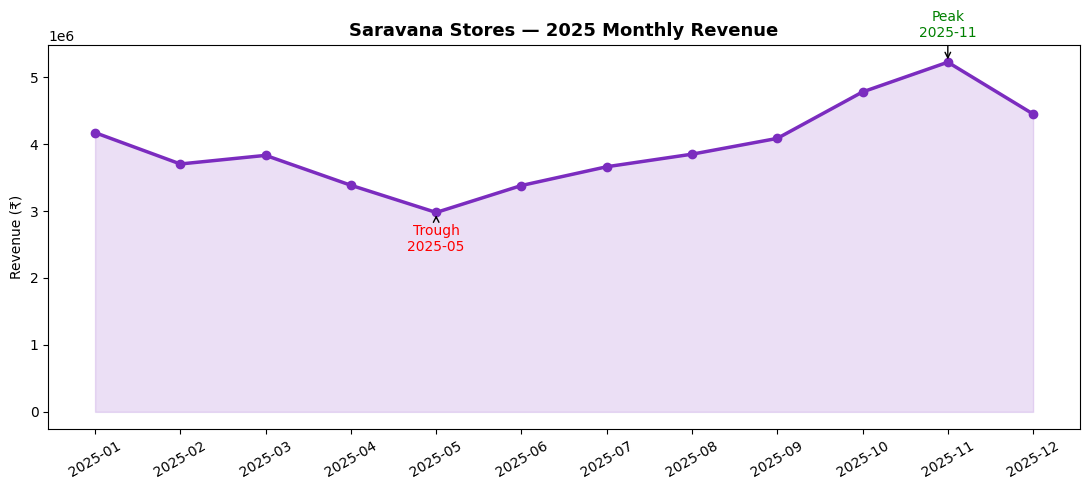

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, marker="o", linewidth=2.5, color="#7B2CBF")
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color="#7B2CBF")
ax.set_title("Saravana Stores — 2025 Monthly Revenue", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (₹)")
ax.tick_params(axis="x", rotation=30)

# Annotate peak and trough
peak_m, trough_m = monthly.idxmax(), monthly.idxmin()
ax.annotate(f"Peak\n{peak_m}", xy=(peak_m, monthly.max()),
            xytext=(0, 18), textcoords="offset points",
            ha="center", color="green",
            arrowprops=dict(arrowstyle="->"))
ax.annotate(f"Trough\n{trough_m}", xy=(trough_m, monthly.min()),
            xytext=(0, -28), textcoords="offset points",
            ha="center", color="red",
            arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
plt.show()

**📝 Finding:** Revenue is strongly seasonal — Q4 (Oct–Dec) is the festival peak driving the biggest months, while Q2 (Apr–Jun) is the trough. Plan staffing, stock and marketing budgets accordingly.

## 🔹 Question 2 — Which branches are winning, which are struggling?

Compare each branch's full-year revenue and growth from H1 (Jan–Jun) to H2 (Jul–Dec).

In [5]:
branch_total = sales.groupby("Branch")["Revenue"].sum().sort_values(ascending=False)
share = (branch_total / branch_total.sum() * 100).round(1)

scoreboard = pd.DataFrame({"Revenue": branch_total, "ShareOfTotal_%": share})
scoreboard["Rank"] = range(1, len(scoreboard) + 1)
print(scoreboard)

                     Revenue  ShareOfTotal_%  Rank
Branch                                            
Chennai          14179100.85            29.9     1
Coimbatore       10110990.06            21.3     2
Madurai           9070195.25            19.1     3
Tiruchirappalli   7937062.12            16.7     4
Salem             6194333.81            13.0     5


In [6]:
# H1 vs H2 growth
sales["Half"] = sales["Month"].apply(lambda m: "H1" if int(m.split("-")[1]) <= 6 else "H2")
half = sales.pivot_table(index="Branch", columns="Half",
                          values="Revenue", aggfunc="sum")
half["Growth_%"] = ((half["H2"] - half["H1"]) / half["H1"] * 100).round(1)
half = half.sort_values("Growth_%", ascending=False)
print(half)

Half                     H1          H2  Growth_%
Branch                                           
Tiruchirappalli  3447532.95  4489529.17      30.2
Coimbatore       4403112.38  5707877.68      29.6
Madurai          4093037.60  4977157.65      21.6
Chennai          6404844.90  7774255.95      21.4
Salem            3098975.70  3095358.11      -0.1


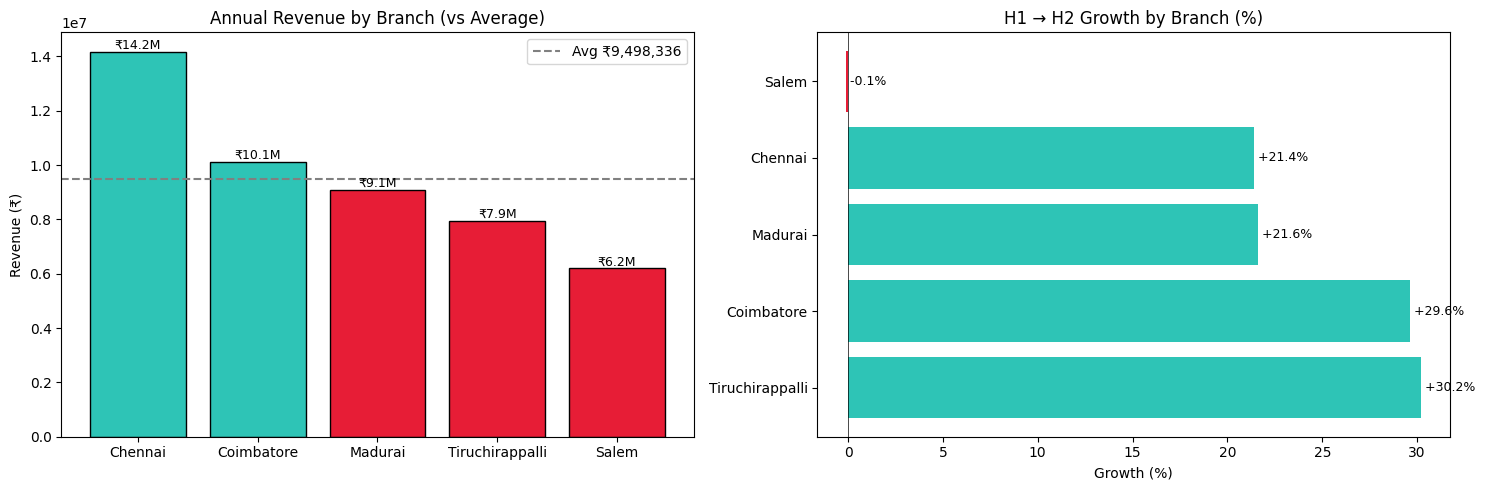

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Revenue by branch
colors = ["#2EC4B6" if v > branch_total.mean() else "#E71D36"
          for v in branch_total.values]
axes[0].bar(branch_total.index, branch_total.values, color=colors,
            edgecolor="black")
axes[0].axhline(branch_total.mean(), color="grey", linestyle="--",
                label=f"Avg ₹{branch_total.mean():,.0f}")
axes[0].set_title("Annual Revenue by Branch (vs Average)")
axes[0].set_ylabel("Revenue (₹)")
axes[0].legend()
for i, v in enumerate(branch_total.values):
    axes[0].text(i, v, f"₹{v/1e6:.1f}M", ha="center", va="bottom", fontsize=9)

# Right: H1 vs H2 growth
growth = half["Growth_%"]
colors = ["#2EC4B6" if v > 0 else "#E71D36" for v in growth.values]
axes[1].barh(growth.index, growth.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.5)
axes[1].set_title("H1 → H2 Growth by Branch (%)")
axes[1].set_xlabel("Growth (%)")
for i, v in enumerate(growth.values):
    axes[1].text(v, i, f" {v:+.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

**📝 Finding:** **Chennai** is the clear leader by absolute revenue. The H1→H2 growth view is more revealing — most branches benefit from the festival season, but **Salem actually contracts** in H2 even though it's the biggest spending half across the chain. That's a red flag worth investigating.

## 🔹 Question 3 — Which product category drives revenue?

In [8]:
cat_rev = sales.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
cat_share = (cat_rev / cat_rev.sum() * 100).round(1)
print(pd.DataFrame({"Revenue": cat_rev, "Share_%": cat_share}))

# Cross-tab: branch × category
crosstab = sales.pivot_table(index="Branch", columns="Category",
                              values="Revenue", aggfunc="sum").round(0)
print("\nRevenue by branch × category:")
print(crosstab.applymap(lambda v: f"₹{v/1e5:.1f}L"))

                 Revenue  Share_%
Category                         
Textiles     15136421.00     31.9
Electronics  11430869.48     24.1
Groceries    10474105.71     22.1
Home          5719229.42     12.0
Stationery    4731056.48     10.0

Revenue by branch × category:
Category        Electronics Groceries    Home Stationery Textiles
Branch                                                           
Chennai              ₹33.9L    ₹31.7L  ₹16.8L     ₹13.9L   ₹45.5L
Coimbatore           ₹24.7L    ₹22.1L  ₹12.3L      ₹9.7L   ₹32.2L
Madurai              ₹22.1L    ₹19.8L  ₹11.0L      ₹9.4L   ₹28.4L
Salem                ₹14.5L    ₹14.0L   ₹7.5L      ₹6.2L   ₹19.8L
Tiruchirappalli      ₹19.1L    ₹17.1L   ₹9.7L      ₹8.0L   ₹25.4L


C:\Users\Surya\AppData\Local\Temp\ipykernel_42764\2834059035.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(crosstab.applymap(lambda v: f"₹{v/1e5:.1f}L"))


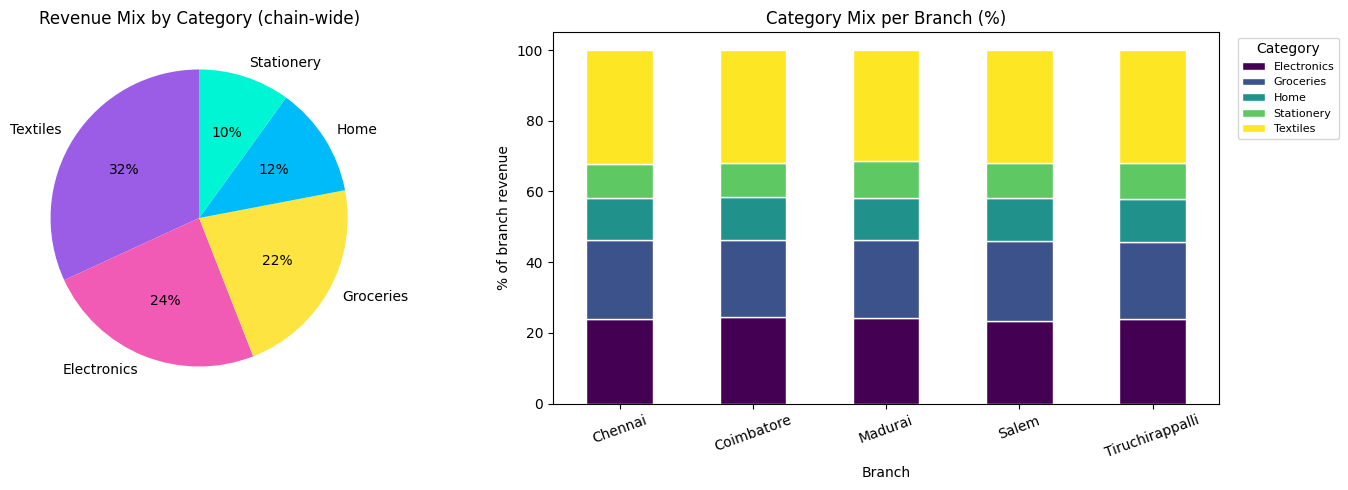

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pie of overall mix
axes[0].pie(cat_rev.values, labels=cat_rev.index, autopct="%1.0f%%",
            colors=["#9B5DE5","#F15BB5","#FEE440","#00BBF9","#00F5D4"],
            startangle=90)
axes[0].set_title("Revenue Mix by Category (chain-wide)")

# Heatmap-ish bar showing crosstab
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
crosstab_pct.plot(kind="bar", stacked=True, ax=axes[1],
                  colormap="viridis", edgecolor="white")
axes[1].set_title("Category Mix per Branch (%)")
axes[1].set_ylabel("% of branch revenue")
axes[1].legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left",
               fontsize=8)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**📝 Finding:** **Textiles** and **Electronics** together drive about 56% of revenue. The category mix is fairly consistent across branches — no branch is dramatically over-indexed on one category, so a chain-wide promotion strategy can work.

## 🔹 Question 4 — What happened at Salem? (Early-warning deep dive)

Question 2 flagged Salem as the only branch contracting in H2. That's worth investigating cell by cell.

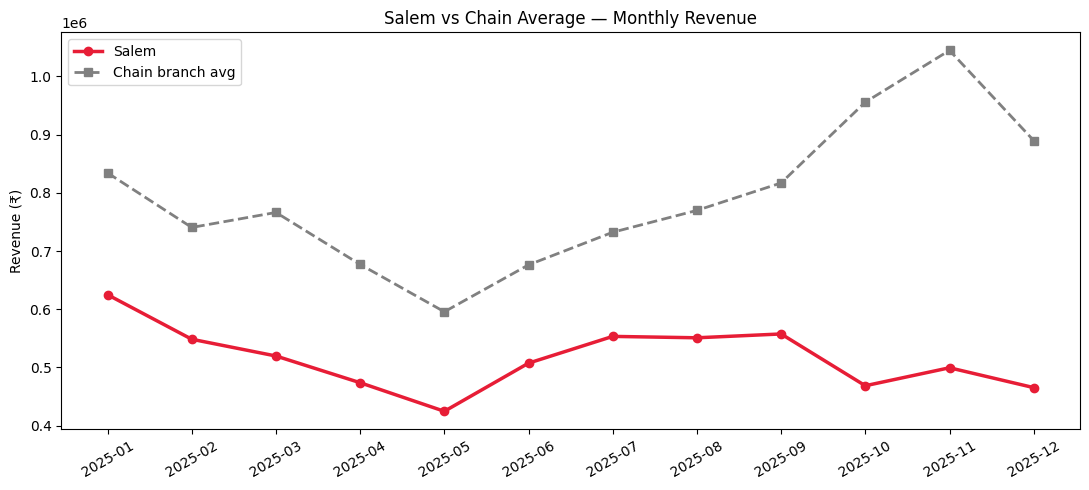


Salem revenue Q3 (Jul-Sep): ₹1,661,860
Salem revenue Q4 (Oct-Dec): ₹1,433,499
Q4 vs Q3 change          : -13.7%


In [10]:
salem = sales[sales["Branch"] == "Salem"].copy()
salem_monthly = salem.groupby("Month")["Revenue"].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(salem_monthly.index, salem_monthly.values, marker="o",
        linewidth=2.5, color="#E71D36", label="Salem")

# Compare against chain average per month
chain_avg = sales.groupby("Month")["Revenue"].sum() / 5
ax.plot(chain_avg.index, chain_avg.values, marker="s",
        linewidth=2, color="grey", linestyle="--",
        label="Chain branch avg")

ax.set_title("Salem vs Chain Average — Monthly Revenue")
ax.set_ylabel("Revenue (₹)")
ax.tick_params(axis="x", rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

print("\nSalem revenue Q3 (Jul-Sep):", f"₹{salem[salem['Month'].isin(['2025-07','2025-08','2025-09'])]['Revenue'].sum():,.0f}")
print("Salem revenue Q4 (Oct-Dec):", f"₹{salem[salem['Month'].isin(['2025-10','2025-11','2025-12'])]['Revenue'].sum():,.0f}")
print("Q4 vs Q3 change          :", f"{(salem[salem['Month'].isin(['2025-10','2025-11','2025-12'])]['Revenue'].sum() / salem[salem['Month'].isin(['2025-07','2025-08','2025-09'])]['Revenue'].sum() - 1) * 100:+.1f}%")

**📝 Finding:** Salem actually **dropped** in Q4 against the chain pattern — every other branch peaked during the festival season but Salem lost ground. Likely causes to verify on-site: management changes, local competition, stock-outs at the wrong moment, or staffing cuts. **This is the single biggest priority for the 2026 turnaround plan.**

## 🔹 Question 5 — Board-ready KPI Dashboard

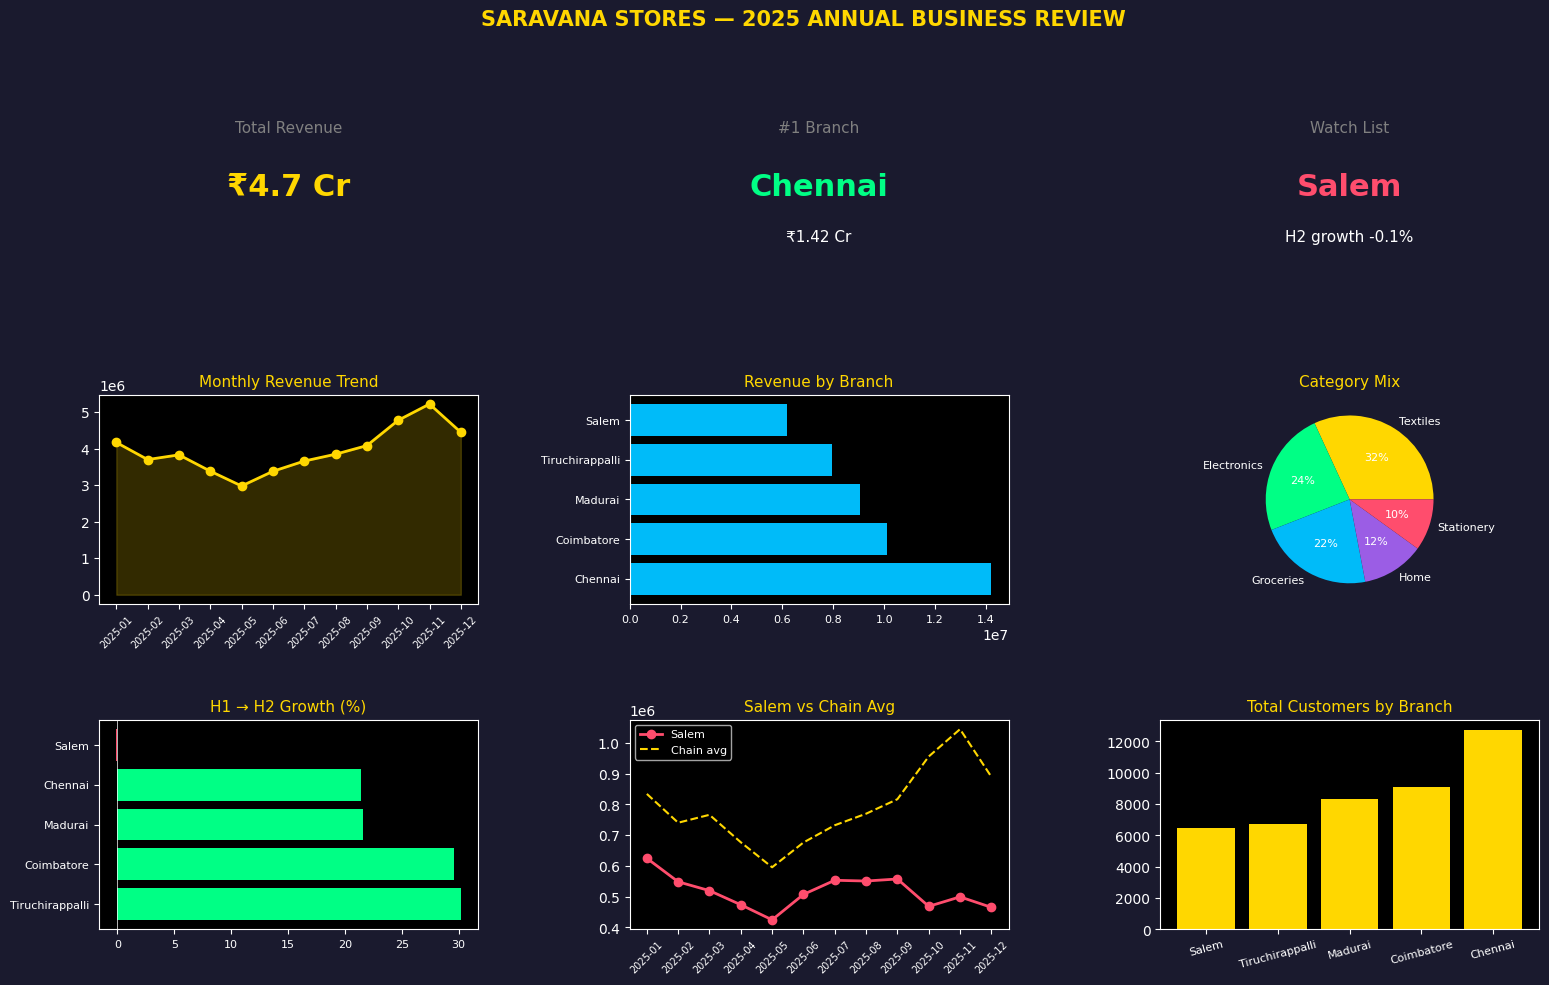

✅ Dashboard saved as case1_dashboard.png


In [11]:
plt.style.use("dark_background")
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#1a1a2e")
fig.suptitle("SARAVANA STORES — 2025 ANNUAL BUSINESS REVIEW",
             fontsize=15, color="#FFD700", fontweight="bold")

GOLD, GREEN, RED, BLUE = "#FFD700", "#00FF85", "#FF4D6D", "#00BBF9"

gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.4,
                      top=0.92, bottom=0.06, left=0.06, right=0.96)

# Panel 1: Total revenue
ax = fig.add_subplot(gs[0, 0]); ax.axis("off")
ax.text(0.5, 0.7, "Total Revenue", ha="center", fontsize=11, color="grey",
        transform=ax.transAxes)
ax.text(0.5, 0.4, f"₹{sales['Revenue'].sum()/1e7:.1f} Cr",
        ha="center", fontsize=22, color=GOLD, fontweight="bold",
        transform=ax.transAxes)

# Panel 2: Best branch
ax = fig.add_subplot(gs[0, 1]); ax.axis("off")
ax.text(0.5, 0.7, "#1 Branch", ha="center", fontsize=11, color="grey",
        transform=ax.transAxes)
ax.text(0.5, 0.4, branch_total.index[0], ha="center", fontsize=22,
        color=GREEN, fontweight="bold", transform=ax.transAxes)
ax.text(0.5, 0.18, f"₹{branch_total.iloc[0]/1e7:.2f} Cr",
        ha="center", fontsize=11, color="white", transform=ax.transAxes)

# Panel 3: Branch needing attention
ax = fig.add_subplot(gs[0, 2]); ax.axis("off")
worst_growth = half["Growth_%"].idxmin()
ax.text(0.5, 0.7, "Watch List", ha="center", fontsize=11, color="grey",
        transform=ax.transAxes)
ax.text(0.5, 0.4, worst_growth, ha="center", fontsize=22,
        color=RED, fontweight="bold", transform=ax.transAxes)
ax.text(0.5, 0.18, f"H2 growth {half['Growth_%'].min():+.1f}%",
        ha="center", fontsize=11, color="white", transform=ax.transAxes)

# Panel 4: Monthly revenue trend
ax = fig.add_subplot(gs[1, 0])
ax.plot(monthly.index, monthly.values, marker="o", color=GOLD, linewidth=2)
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color=GOLD)
ax.set_title("Monthly Revenue Trend", color=GOLD, fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=7, colors="white")
ax.tick_params(axis="y", colors="white")

# Panel 5: Branch leaderboard
ax = fig.add_subplot(gs[1, 1])
ax.barh(branch_total.index, branch_total.values, color=BLUE)
ax.set_title("Revenue by Branch", color=GOLD, fontsize=11)
ax.tick_params(colors="white", labelsize=8)

# Panel 6: Category mix pie
ax = fig.add_subplot(gs[1, 2])
ax.pie(cat_rev.values, labels=cat_rev.index, autopct="%1.0f%%",
       colors=[GOLD, GREEN, BLUE, "#9B5DE5", RED],
       textprops={"color": "white", "fontsize": 8})
ax.set_title("Category Mix", color=GOLD, fontsize=11)

# Panel 7: H1 vs H2 growth
ax = fig.add_subplot(gs[2, 0])
g = half["Growth_%"]
colors = [GREEN if v > 0 else RED for v in g.values]
ax.barh(g.index, g.values, color=colors)
ax.axvline(0, color="white", linewidth=0.5)
ax.set_title("H1 → H2 Growth (%)", color=GOLD, fontsize=11)
ax.tick_params(colors="white", labelsize=8)

# Panel 8: Salem vs chain avg
ax = fig.add_subplot(gs[2, 1])
ax.plot(salem_monthly.index, salem_monthly.values, marker="o",
        color=RED, linewidth=2, label="Salem")
ax.plot(chain_avg.index, chain_avg.values, color=GOLD,
        linestyle="--", linewidth=1.5, label="Chain avg")
ax.set_title("Salem vs Chain Avg", color=GOLD, fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=7, colors="white")
ax.tick_params(axis="y", colors="white")
ax.legend(fontsize=8)

# Panel 9: Customers by branch
ax = fig.add_subplot(gs[2, 2])
cust_by_branch = sales.groupby("Branch")["Customers"].sum().sort_values()
ax.bar(cust_by_branch.index, cust_by_branch.values, color=GOLD)
ax.set_title("Total Customers by Branch", color=GOLD, fontsize=11)
ax.tick_params(axis="x", rotation=15, colors="white", labelsize=8)
ax.tick_params(axis="y", colors="white")

plt.savefig("case1_dashboard.png", dpi=130, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
plt.style.use("default")
print("✅ Dashboard saved as case1_dashboard.png")

## 📋 Recommendations for FY 2026

Based on the analysis above, here are 3 specific recommendations for Mr. Saravanan:

### 1️⃣ Immediate — investigate Salem branch (this week)
**Finding:** Salem is the only branch where Q4 was *worse* than Q3, contracting against the chain-wide festival pattern.
**Action:** Send a regional manager for a 3-day on-site review covering staffing, local competition, stock availability and customer complaints.
**Expected impact:** Restoring Salem to chain-average growth could recover roughly ₹35–50 lakh of annual revenue.

### 2️⃣ Short-term — protect Q4 stock & staffing (by August 2026)
**Finding:** Q4 (Oct–Dec) generates ~32% of annual revenue; April–June only ~21%.
**Action:** Re-time inventory orders so peak SKUs land by 1 October; hire seasonal staff for Oct–Dec and reduce headcount or shift schedules in Apr–Jun.
**Expected impact:** Better Q4 stock availability could lift festival revenue 5–8%.

### 3️⃣ Strategic — double-down on Textiles + Electronics (FY26 plan)
**Finding:** Textiles + Electronics drive ~56% of chain revenue, with consistent share across all branches.
**Action:** Negotiate annual volume contracts with top suppliers in these two categories; allocate the largest share of the marketing budget to festival campaigns built around them.
**Expected impact:** A 3-percentage-point share gain in either category translates to roughly ₹30 lakh of additional annual revenue.

---

## ✏️ Practice extensions

If you want to take this further, try:
- Compute **YoY growth** by adding 2024 data and calculating Year-over-Year change
- Forecast 2026 monthly revenue using a simple linear trend (`numpy.polyfit`)
- Build a **branch profitability** view by adding a cost dataset
- Identify the **top 3 SKUs** in each category to drive the volume contract negotiation